Objective:

To develop an accurate and reliable weather forecasting system using historical weather data. The project will utilize various machine learning algorithms to predict weather conditions based on historical patterns

Data Description:


    Source: Kaggle Dataset "Indian Summer - Over the Years"
    Features:
        City
        Date
        Max Temperature (tempmax)
        Min Temperature (tempmin)
        Average Temperature (temp)
        Feels Like Max (feelslikemax)
        Feels Like Min (feelslikemin)
        Average Feels Like (feelslike)
        Dew Point (dew)
        Humidity (humidity)
        Wind Speed (windspeed)
        Wind Direction (winddir)
        Sea Level Pressure (sealevelpressure)
        Cloud Cover (cloudcover)
        Visibility (visibility)
        Sunrise Time (sunrise)
        Sunset Time (sunset)
        Moon Phase (moonphase)
        Weather Conditions (conditions)
        Description (description)

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.impute import SimpleImputer
from scipy.stats import zscore
from scipy.stats import boxcox
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel


from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline



Data Collection:

In [2]:
# Load the dataset
data = pd.read_csv("indian _Summer_Weather.csv")
data


,City,Date,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,windspeed,winddir,sealevelpressure,cloudcover,visibility,sunrise,sunset,moonphase,conditions,description
0,New Delhi,01-04-2021,34.0,19.0,27.1,31.6,19.0,26.1,3.1,22.60,22.8,272.9,1002.8,0.0,3.1,01-04-2021 06:11,01-04-2021 18:39,0.60,Clear,Clear conditions throughout the day.
1,New Delhi,02-04-2021,33.9,16.0,25.8,31.8,16.0,24.9,4.5,27.62,12.4,275.0,1006.2,0.0,3.5,02-04-2021 06:10,02-04-2021 18:39,0.65,Clear,Clear conditions throughout the day.
2,New Delhi,03-04-2021,34.8,14.6,26.0,32.2,14.6,25.1,1.3,23.18,16.5,127.5,1008.8,1.4,3.5,03-04-2021 06:08,03-04-2021 18:40,0.70,Clear,Clear conditions throughout the day.
3,New Delhi,04-04-2021,36.8,16.9,27.1,34.2,16.9,26.0,4.8,28.00,18.3,157.6,1009.5,2.6,3.2,04-04-2021 06:07,04-04-2021 18:40,0.76,Clear,Clear conditions throughout the day.
4,New Delhi,05-04-2021,38.8,21.0,29.9,37.1,21.0,28.9,8.1,28.85,13.5,100.4,1007.8,38.4,3.1,05-04-2021 06:06,05-04-2021 18:41,0.81,Partially cloudy,Partly cloudy throughout the day.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20377,Hyderabad,26-06-2007,29.1,23.1,26.5,30.9,23.1,27.6,21.3,73.67,24.1,NaN,NaN,97.6,3.4,26-06-2007 05:43,26-06-2007 18:53,0.42,"Rain, Overcast",Cloudy skies throughout the day with afternoon...
20378,Hyderabad,27-06-2007,29.1,24.1,26.3,32.9,24.1,27.3,21.4,74.96,27.7,NaN,NaN,93.8,4.3,27-06-2007 05:44,27-06-2007 18:53,0.45,"Rain, Overcast",Cloudy skies throughout the day with rain.
20379,Hyderabad,28-06-2007,29.1,25.1,26.8,31.4,25.1,27.7,20.6,69.17,27.7,NaN,NaN,93.8,4.6,28-06-2007 05:44,28-06-2007 18:54,0.48,"Rain, Overcast",Cloudy skies throughout the day with late afte...
20380,Hyderabad,29-06-2007,27.1,24.1,26.2,28.6,24.1,26.9,20.3,70.24,25.9,NaN,NaN,98.8,5.0,29-06-2007 05:44,29-06-2007 18:54,0.49,"Rain, Overcast",Cloudy skies throughout the day with rain.


In [3]:
# Display the first few rows of the dataset
print("First few rows of the dataset:")
print(data.head())

# Summary statistics of the dataset
print("\nSummary statistics:")
print(data.describe())

# Data types and non-null values
print("\nData types and non-null values:")
print(data.info())



First few rows of the dataset:
        City        Date  tempmax  tempmin  temp  feelslikemax  feelslikemin  \
0  New Delhi  01-04-2021     34.0     19.0  27.1          31.6          19.0   
1  New Delhi  02-04-2021     33.9     16.0  25.8          31.8          16.0   
2  New Delhi  03-04-2021     34.8     14.6  26.0          32.2          14.6   
3  New Delhi  04-04-2021     36.8     16.9  27.1          34.2          16.9   
4  New Delhi  05-04-2021     38.8     21.0  29.9          37.1          21.0   

   feelslike  dew  humidity  windspeed  winddir  sealevelpressure  cloudcover  \
0       26.1  3.1     22.60       22.8    272.9            1002.8         0.0   
1       24.9  4.5     27.62       12.4    275.0            1006.2         0.0   
2       25.1  1.3     23.18       16.5    127.5            1008.8         1.4   
3       26.0  4.8     28.00       18.3    157.6            1009.5         2.6   
4       28.9  8.1     28.85       13.5    100.4            1007.8        38.4   

 

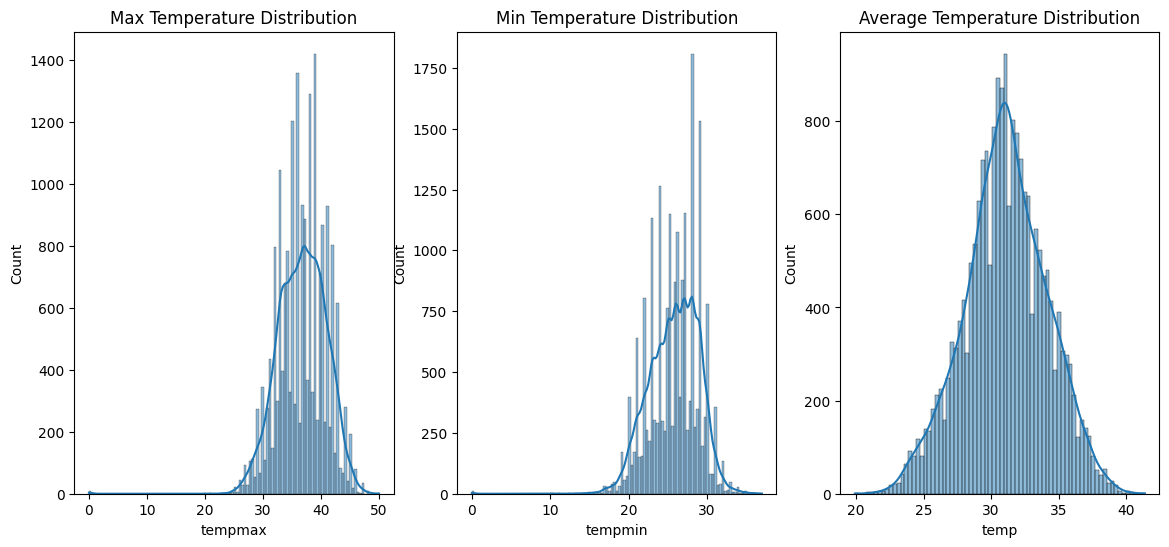

In [4]:
# Distribution of temperature-related features
plt.figure(figsize=(14, 6))
plt.subplot(1, 3, 1)
sns.histplot(data['tempmax'], kde=True)
plt.title('Max Temperature Distribution')

plt.subplot(1, 3, 2)
sns.histplot(data['tempmin'], kde=True)
plt.title('Min Temperature Distribution')

plt.subplot(1, 3, 3)
sns.histplot(data['temp'], kde=True)
plt.title('Average Temperature Distribution')
plt.show()



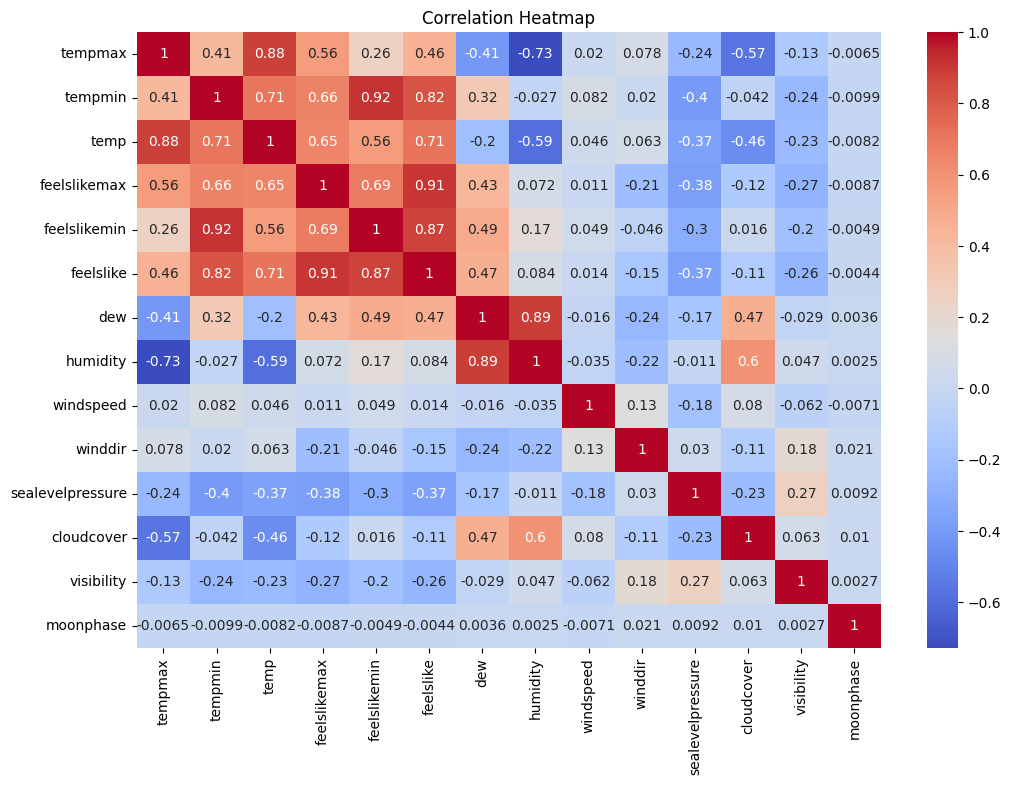

In [5]:
# Select numeric columns only
numeric_data = data.select_dtypes(include=['float64', 'int64'])

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()



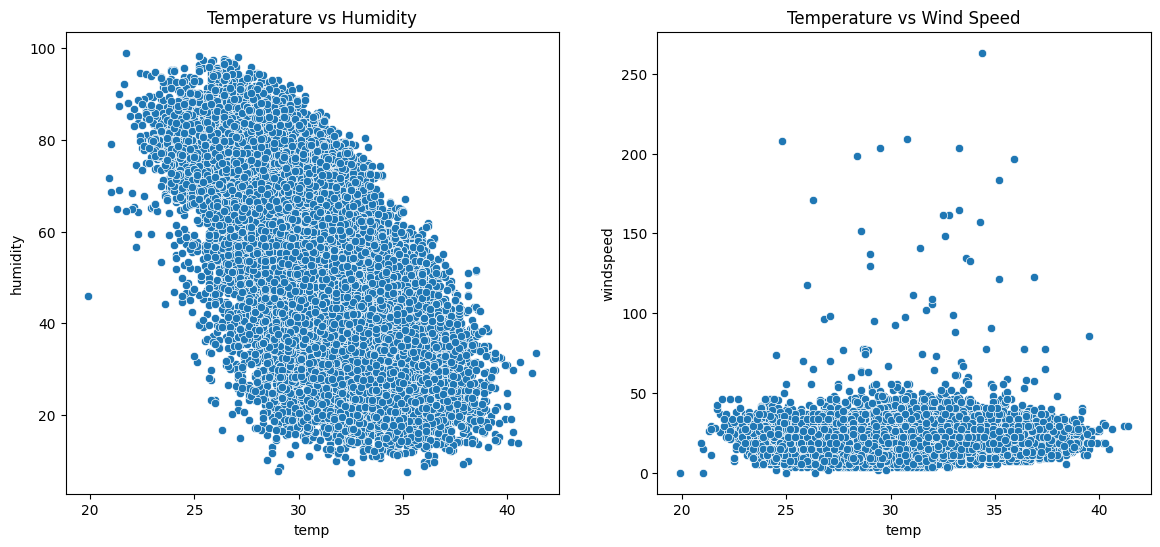

In [6]:
# Relationships between temperature and other features
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x='temp', y='humidity', data=data)
plt.title('Temperature vs Humidity')

plt.subplot(1, 2, 2)
sns.scatterplot(x='temp', y='windspeed', data=data)
plt.title('Temperature vs Wind Speed')
plt.show()



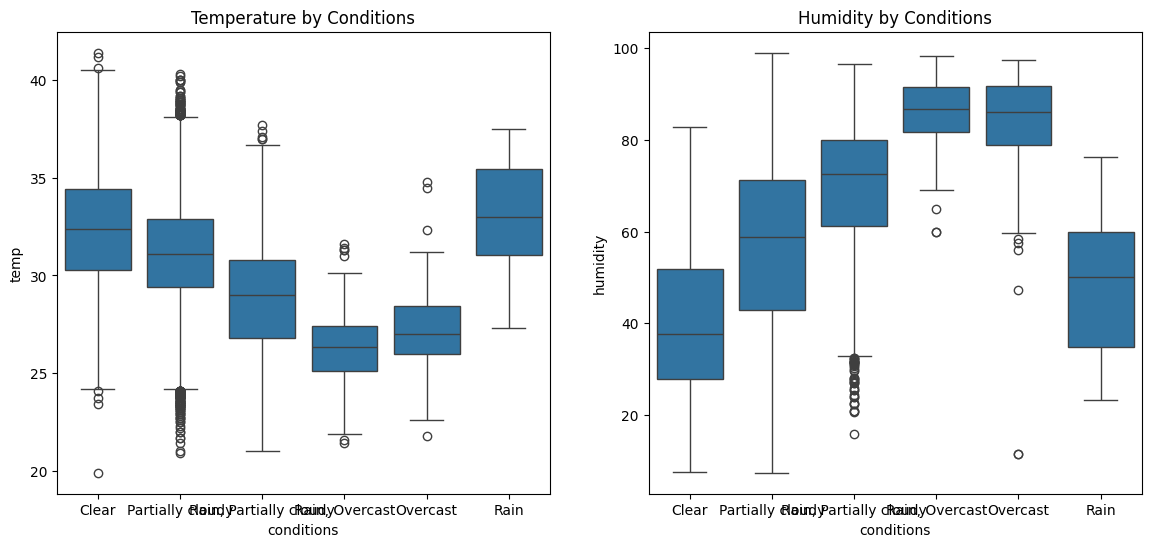

In [7]:
# Box plots for categorical features
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='conditions', y='temp', data=data)
plt.title('Temperature by Conditions')

plt.subplot(1, 2, 2)
sns.boxplot(x='conditions', y='humidity', data=data)
plt.title('Humidity by Conditions')
plt.show()



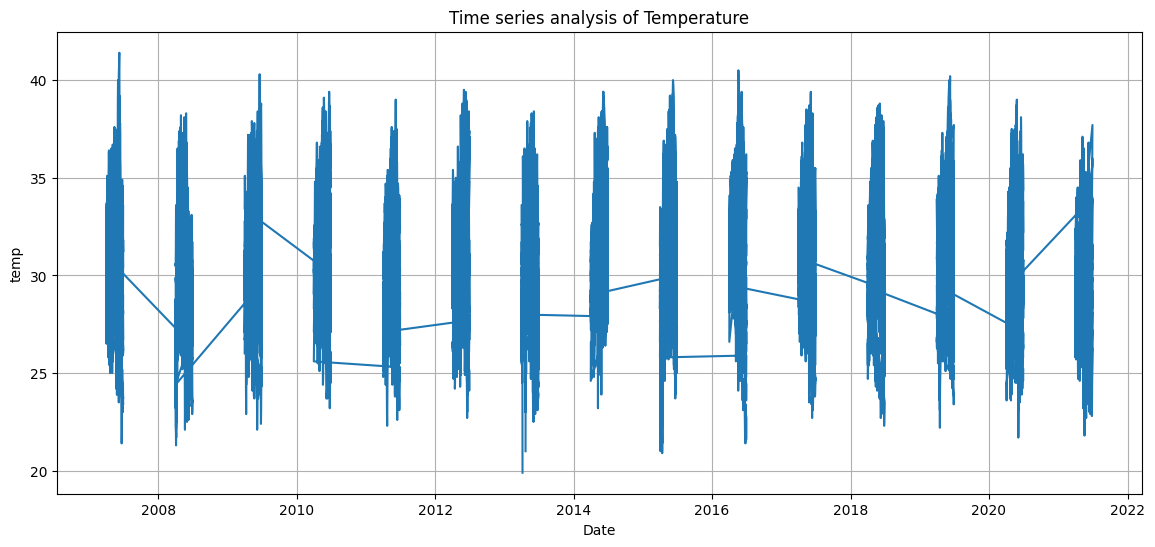

In [8]:
# Convert 'Date' column to datetime format
data['Date'] = pd.to_datetime(data['Date'], format='%d-%m-%Y')

# Set 'Date' column as index
data.set_index('Date', inplace=True)

# Check if 'Temperature' column exists in the DataFrame
if 'temp' in data.columns:
    # Plotting temperature data
    plt.figure(figsize=(14, 6))
    plt.plot(data.index, data['temp'])
    plt.title('Time series analysis of Temperature')
    plt.xlabel('Date')
    plt.ylabel('temp')
    plt.grid(True)
    plt.show()
else:
    print("Error: 'Temperature' column not found in DataFrame.")

Data Preprocessing - Data Cleaning:

In [9]:
# Handle missing values using appropriate imputation techniques
# For numerical columns, use the mean; for categorical columns, use the most frequent value
numerical_cols = data.select_dtypes(include=[np.number]).columns
categorical_cols = data.select_dtypes(include=[object]).columns

imputer_num = SimpleImputer(strategy='mean')
data[numerical_cols] = imputer_num.fit_transform(data[numerical_cols])

imputer_cat = SimpleImputer(strategy='most_frequent')
data[categorical_cols] = imputer_cat.fit_transform(data[categorical_cols])



In [10]:
def remove_outliers_iqr(df):
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    for col in numerical_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df



In [11]:
# Remove outliers in numerical columns using the Box Plot method
data_cleaned = remove_outliers_iqr(data)

print("Original DataFrame:")
print(data)
print("\nDataFrame after removing outliers:")
print(data_cleaned)





Original DataFrame:
                 City  tempmax  tempmin  temp  feelslikemax  feelslikemin  \
Date                                                                        
2021-04-01  New Delhi     34.0     19.0  27.1          31.6          19.0   
2021-04-02  New Delhi     33.9     16.0  25.8          31.8          16.0   
2021-04-03  New Delhi     34.8     14.6  26.0          32.2          14.6   
2021-04-04  New Delhi     36.8     16.9  27.1          34.2          16.9   
2021-04-05  New Delhi     38.8     21.0  29.9          37.1          21.0   
...               ...      ...      ...   ...           ...           ...   
2007-06-26  Hyderabad     29.1     23.1  26.5          30.9          23.1   
2007-06-27  Hyderabad     29.1     24.1  26.3          32.9          24.1   
2007-06-28  Hyderabad     29.1     25.1  26.8          31.4          25.1   
2007-06-29  Hyderabad     27.1     24.1  26.2          28.6          24.1   
2007-06-30  Hyderabad     28.1     24.1  26.2          2

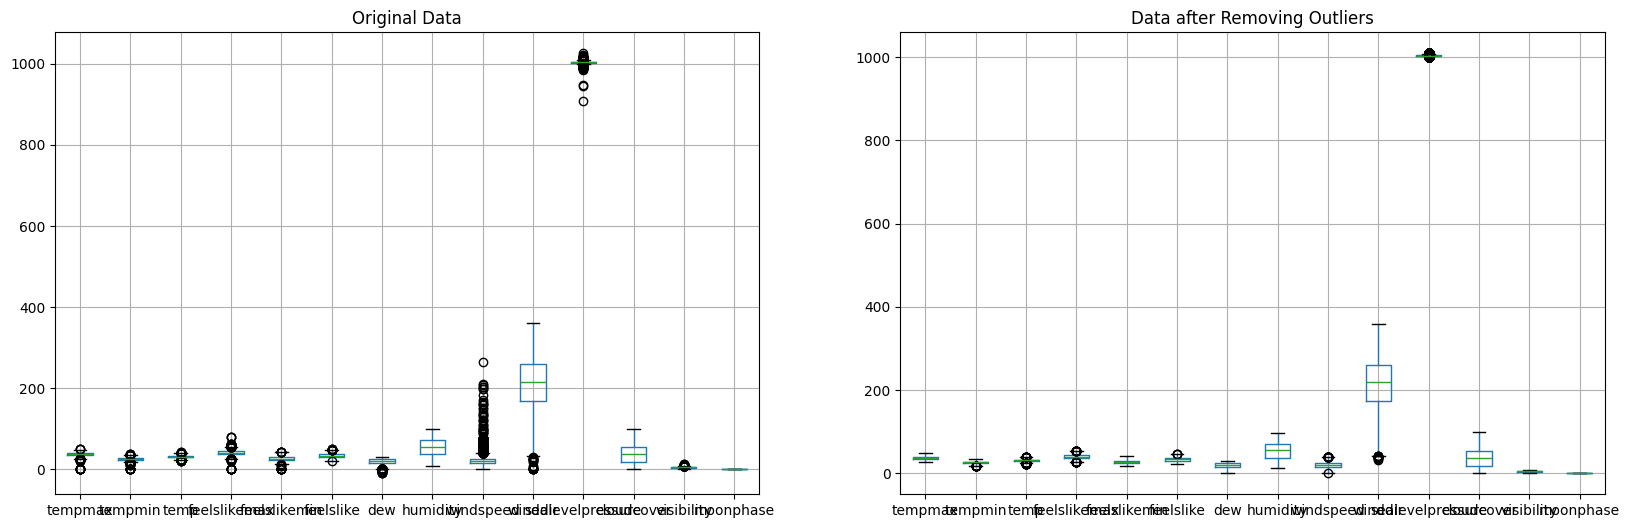

In [12]:
plt.figure(figsize=(20, 6))

# Box plot for original data
plt.subplot(1, 2, 1)
data.boxplot()
plt.title('Original Data')

# Box plot for cleaned data
plt.subplot(1, 2, 2)
data_cleaned.boxplot()
plt.title('Data after Removing Outliers')

plt.show()


Cleaned and transformed data:
                 City  tempmax  tempmin  temp  feelslikemax  feelslikemin  \
Date                                                                        
2021-04-01  New Delhi     34.0     19.0  27.1          31.6          19.0   
2021-04-05  New Delhi     38.8     21.0  29.9          37.1          21.0   
2021-04-06  New Delhi     38.0     22.6  30.4          37.2          22.6   
2021-04-07  New Delhi     36.0     23.4  29.6          34.6          23.4   
2021-04-08  New Delhi     34.9     20.9  27.6          32.6          20.9   

            feelslike   dew  humidity  windspeed  winddir  sealevelpressure  \
Date                                                                          
2021-04-01       26.1   3.1     22.60       22.8    272.9            1002.8   
2021-04-05       28.9   8.1     28.85       13.5    100.4            1007.8   
2021-04-06       29.5  10.2     30.51       14.8    102.0            1006.2   
2021-04-07       28.7   9.7     31

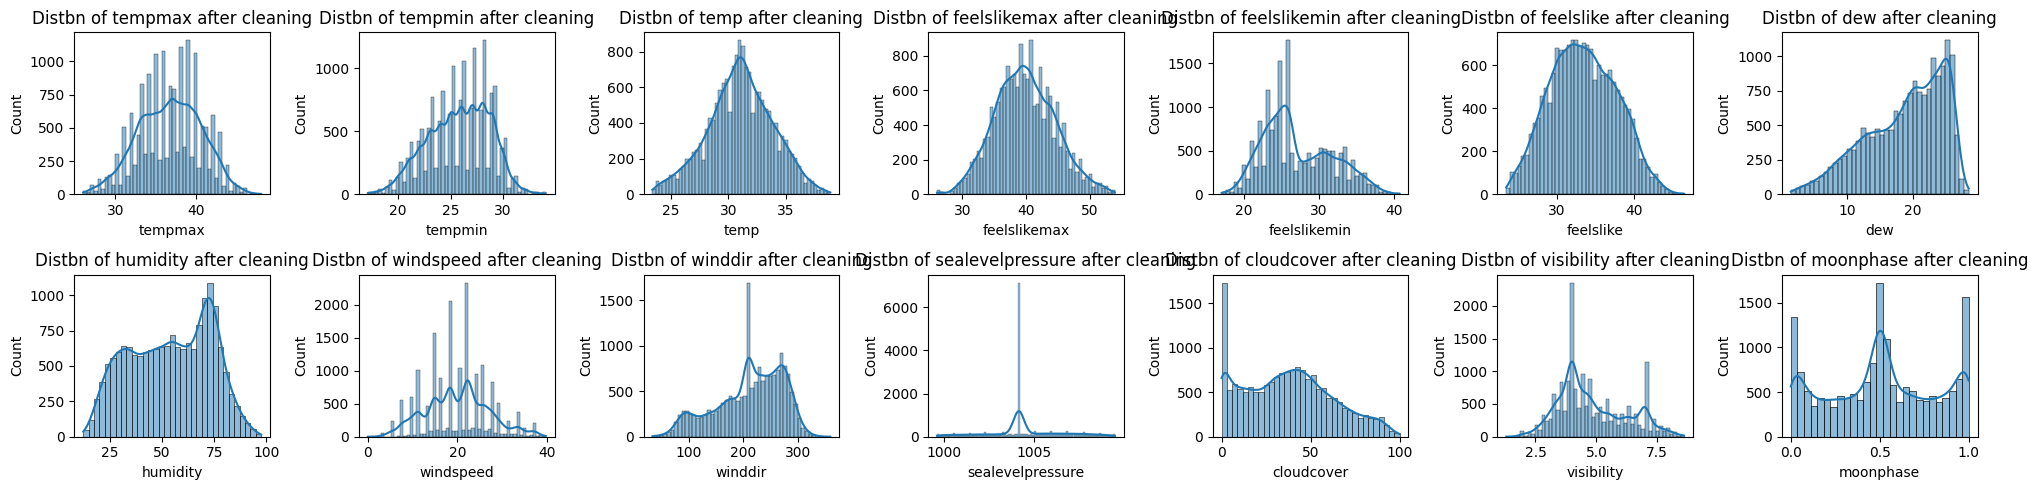

In [13]:
# Verify transformations and clean data
print("\nCleaned and transformed data:")
print(data_cleaned.head())

# Visualize the distribution after cleaning and transformations
plt.figure(figsize=(20,5))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, len(numerical_cols) // 2, i)
    sns.histplot(data_cleaned[col], kde=True)
    plt.title(f'Distbn of {col} after cleaning')
plt.tight_layout()
plt.show()



In [14]:
# Save cleaned data to a new CSV file
data_cleaned.to_csv('cleaned_dataset.csv', index=False)
print("Cleaned data saved to 'cleaned_dataset.csv'")

Cleaned data saved to 'cleaned_dataset.csv'


Exploratory Data Analysis (EDA)

In [15]:

# Load the dataset
data1 = pd.read_csv("cleaned_dataset.csv") 
data1



,City,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,windspeed,winddir,sealevelpressure,cloudcover,visibility,sunrise,sunset,moonphase,conditions,description
0,New Delhi,34.0,19.0,27.1,31.6,19.0,26.1,3.1,22.60,22.8,272.900000,1002.800000,0.0,3.1,01-04-2021 06:11,01-04-2021 18:39,0.60,Clear,Clear conditions throughout the day.
1,New Delhi,38.8,21.0,29.9,37.1,21.0,28.9,8.1,28.85,13.5,100.400000,1007.800000,38.4,3.1,05-04-2021 06:06,05-04-2021 18:41,0.81,Partially cloudy,Partly cloudy throughout the day.
2,New Delhi,38.0,22.6,30.4,37.2,22.6,29.5,10.2,30.51,14.8,102.000000,1006.200000,30.7,2.4,06-04-2021 06:05,06-04-2021 18:41,0.86,Partially cloudy,Partly cloudy throughout the day.
3,New Delhi,36.0,23.4,29.6,34.6,23.4,28.7,9.7,31.69,18.4,220.800000,1009.000000,24.1,2.7,07-04-2021 06:04,07-04-2021 18:42,0.91,Partially cloudy,Partly cloudy throughout the day.
4,New Delhi,34.9,20.9,27.6,32.6,20.9,26.7,4.4,26.47,15.9,259.700000,1009.100000,0.0,3.2,08-04-2021 06:03,08-04-2021 18:43,0.94,Clear,Clear conditions throughout the day.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16972,Hyderabad,29.1,23.1,26.5,30.9,23.1,27.6,21.3,73.67,24.1,208.932799,1004.149954,97.6,3.4,26-06-2007 05:43,26-06-2007 18:53,0.42,"Rain, Overcast",Cloudy skies throughout the day with afternoon...
16973,Hyderabad,29.1,24.1,26.3,32.9,24.1,27.3,21.4,74.96,27.7,208.932799,1004.149954,93.8,4.3,27-06-2007 05:44,27-06-2007 18:53,0.45,"Rain, Overcast",Cloudy skies throughout the day with rain.
16974,Hyderabad,29.1,25.1,26.8,31.4,25.1,27.7,20.6,69.17,27.7,208.932799,1004.149954,93.8,4.6,28-06-2007 05:44,28-06-2007 18:54,0.48,"Rain, Overcast",Cloudy skies throughout the day with late afte...
16975,Hyderabad,27.1,24.1,26.2,28.6,24.1,26.9,20.3,70.24,25.9,208.932799,1004.149954,98.8,5.0,29-06-2007 05:44,29-06-2007 18:54,0.49,"Rain, Overcast",Cloudy skies throughout the day with rain.


In [16]:
# Display the first few rows of the dataset
print("First few rows of the dataset1:")
print(data1.head())

# Summary statistics of the dataset
print("\nSummary statistics:")
print(data1.describe())

# Data types and non-null values
print("\nData types and non-null values:")
print(data1.info())



First few rows of the dataset1:
        City  tempmax  tempmin  temp  feelslikemax  feelslikemin  feelslike  \
0  New Delhi     34.0     19.0  27.1          31.6          19.0       26.1   
1  New Delhi     38.8     21.0  29.9          37.1          21.0       28.9   
2  New Delhi     38.0     22.6  30.4          37.2          22.6       29.5   
3  New Delhi     36.0     23.4  29.6          34.6          23.4       28.7   
4  New Delhi     34.9     20.9  27.6          32.6          20.9       26.7   

    dew  humidity  windspeed  winddir  sealevelpressure  cloudcover  \
0   3.1     22.60       22.8    272.9            1002.8         0.0   
1   8.1     28.85       13.5    100.4            1007.8        38.4   
2  10.2     30.51       14.8    102.0            1006.2        30.7   
3   9.7     31.69       18.4    220.8            1009.0        24.1   
4   4.4     26.47       15.9    259.7            1009.1         0.0   

   visibility           sunrise            sunset  moonphase  \
0 

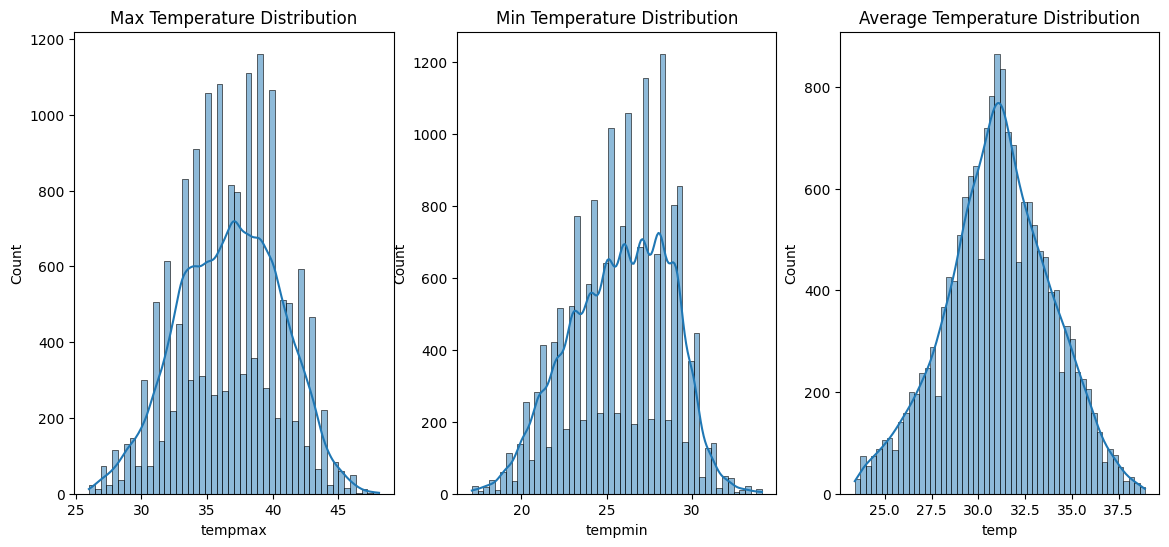

In [17]:
# Distribution of temperature-related features using histograms
plt.figure(figsize=(14, 6))
plt.subplot(1, 3, 1)
sns.histplot(data1['tempmax'], kde=True)
plt.title('Max Temperature Distribution')

plt.subplot(1, 3, 2)
sns.histplot(data1['tempmin'], kde=True)
plt.title('Min Temperature Distribution')

plt.subplot(1, 3, 3)
sns.histplot(data1['temp'], kde=True)
plt.title('Average Temperature Distribution')
plt.show()



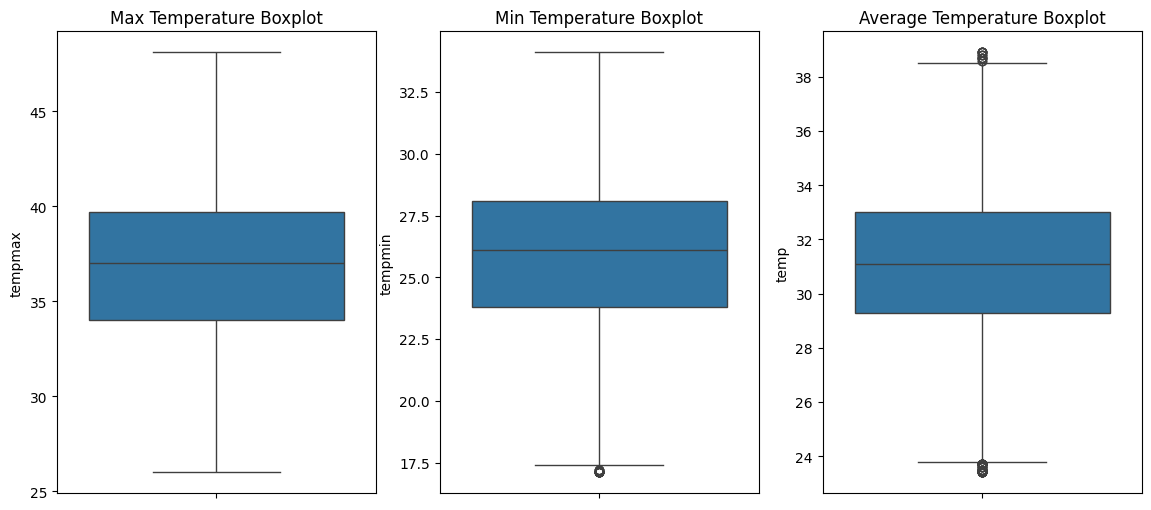

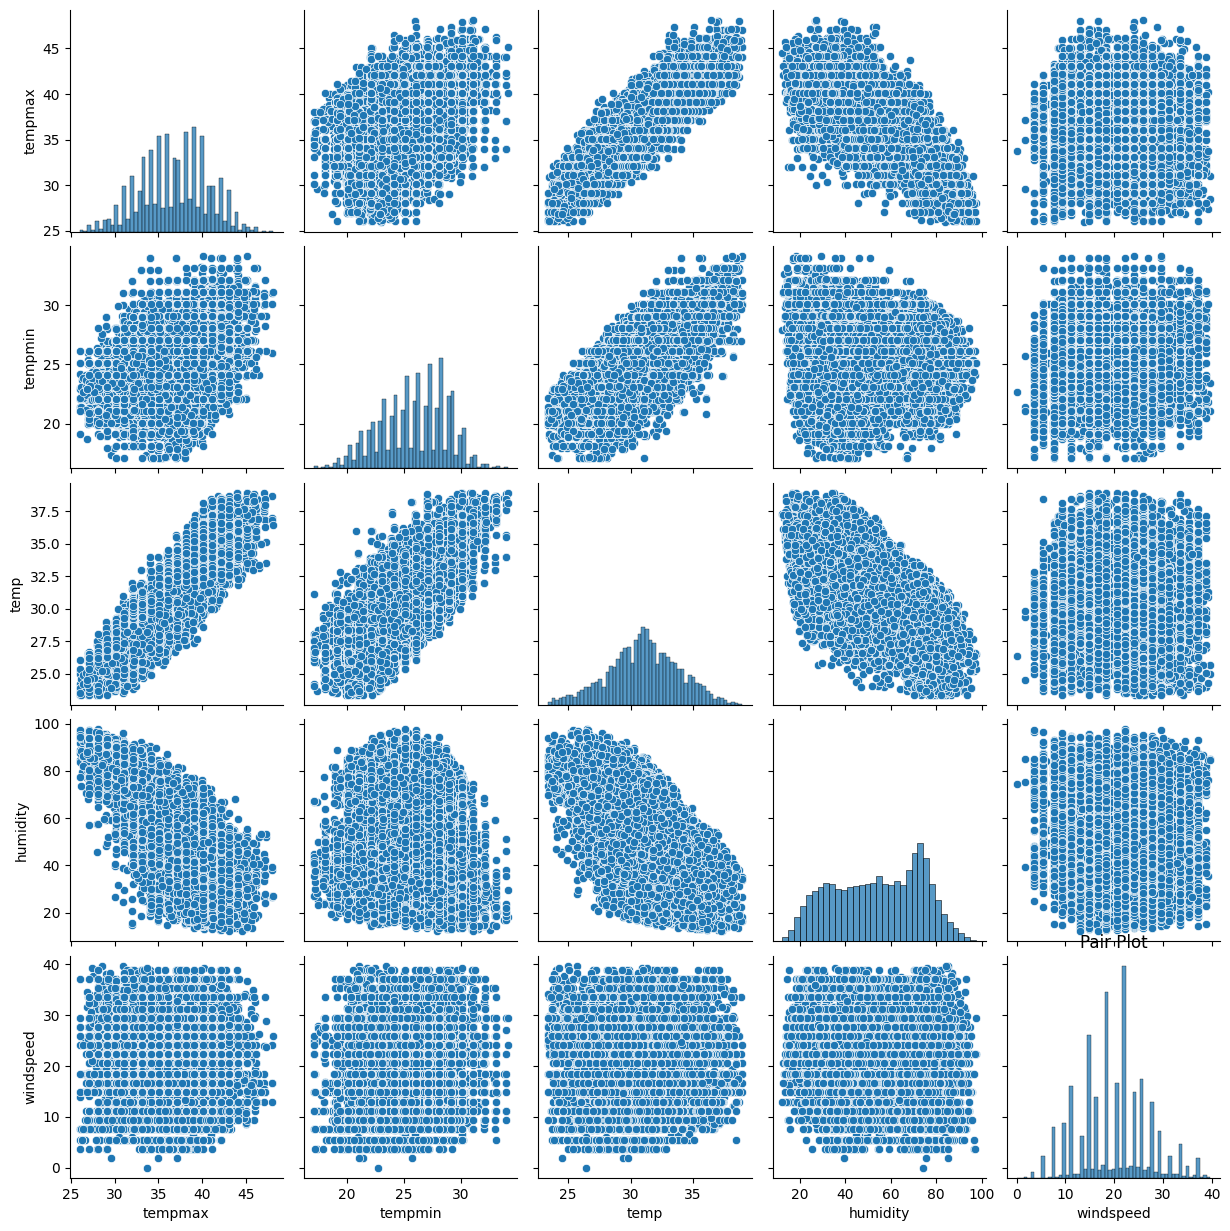

In [18]:
# Boxplots for temperature-related features
plt.figure(figsize=(14, 6))
plt.subplot(1, 3, 1)
sns.boxplot(data1['tempmax'])
plt.title('Max Temperature Boxplot')

plt.subplot(1, 3, 2)
sns.boxplot(data1['tempmin'])
plt.title('Min Temperature Boxplot')

plt.subplot(1, 3, 3)
sns.boxplot(data1['temp'])
plt.title('Average Temperature Boxplot')
plt.show()

# Pair plot to analyze relationships between features
sns.pairplot(data1[['tempmax', 'tempmin', 'temp', 'humidity', 'windspeed']])
plt.title('Pair Plot')
plt.show()



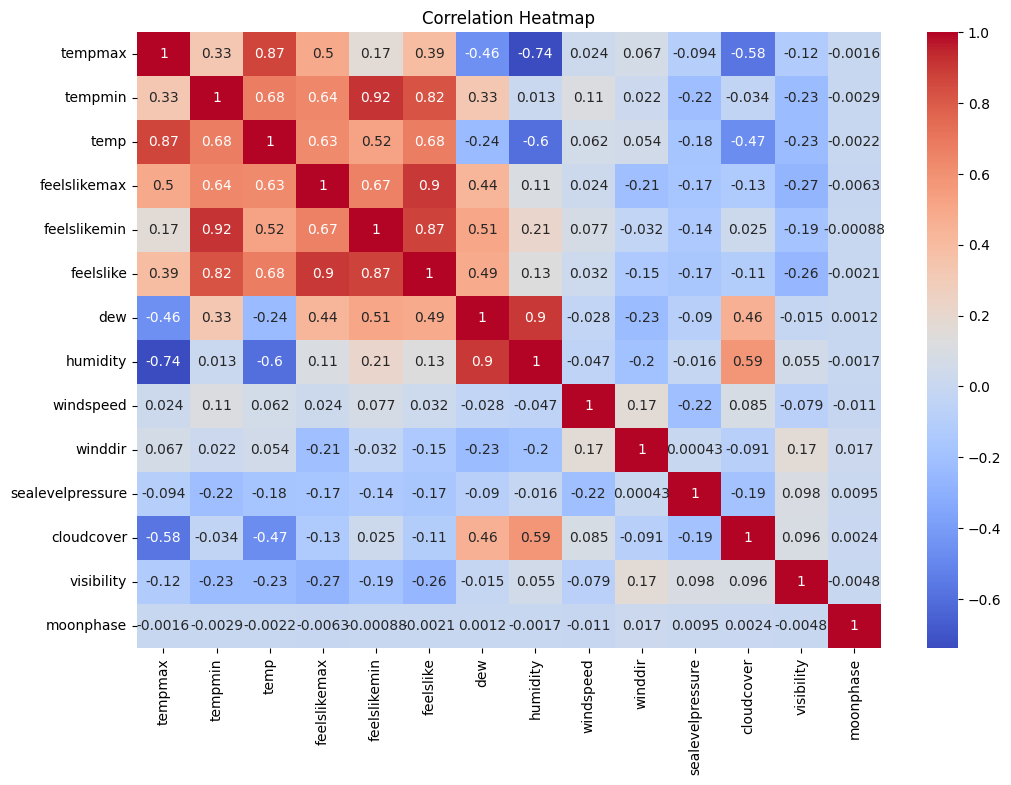

In [19]:
# Correlation heatmap
numeric_data = data1.select_dtypes(include=[np.number])

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


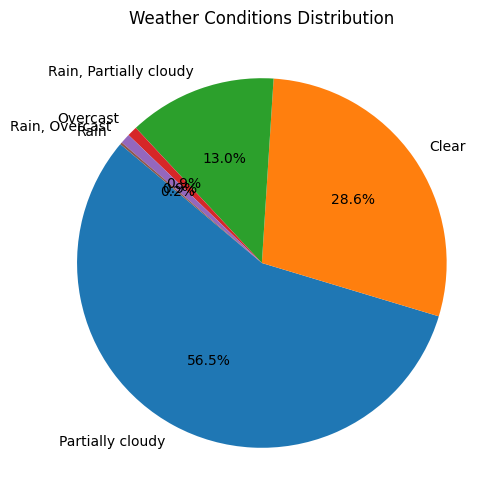

In [20]:
# Pie chart for weather conditions
condition_counts = data1['conditions'].value_counts()
plt.figure(figsize=(10, 6))
plt.pie(condition_counts, labels=condition_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Weather Conditions Distribution')
plt.show()



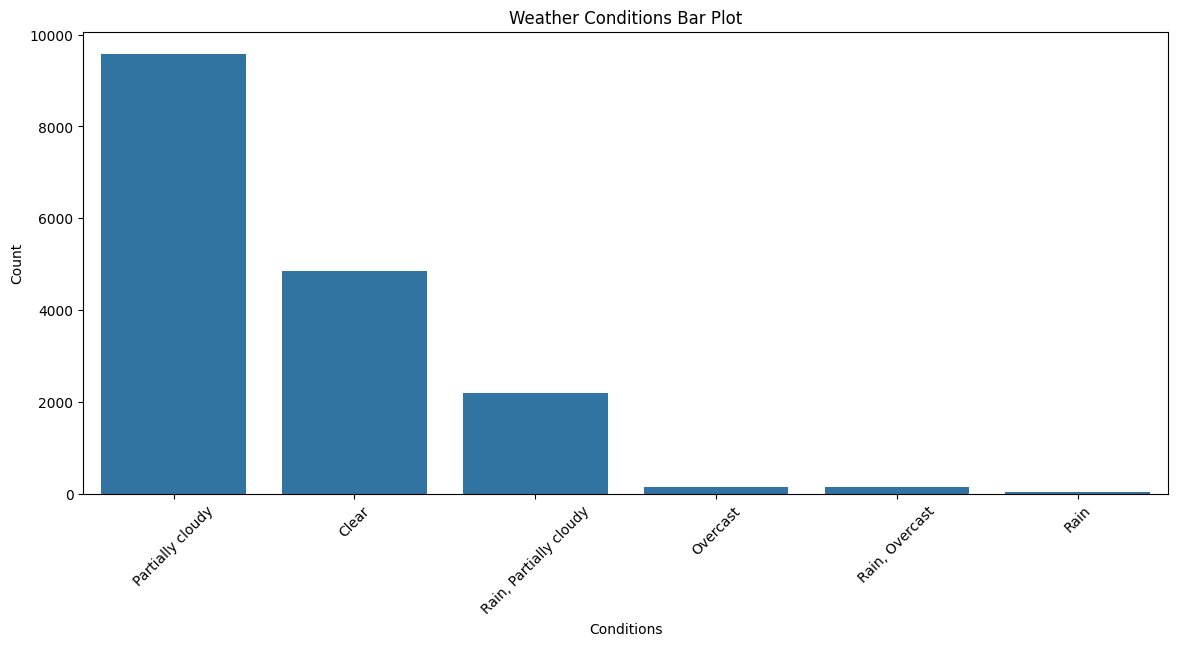

In [21]:
# Bar plot for weather conditions
plt.figure(figsize=(14, 6))
sns.barplot(x=condition_counts.index, y=condition_counts.values)
plt.title('Weather Conditions Bar Plot')
plt.xlabel('Conditions')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()



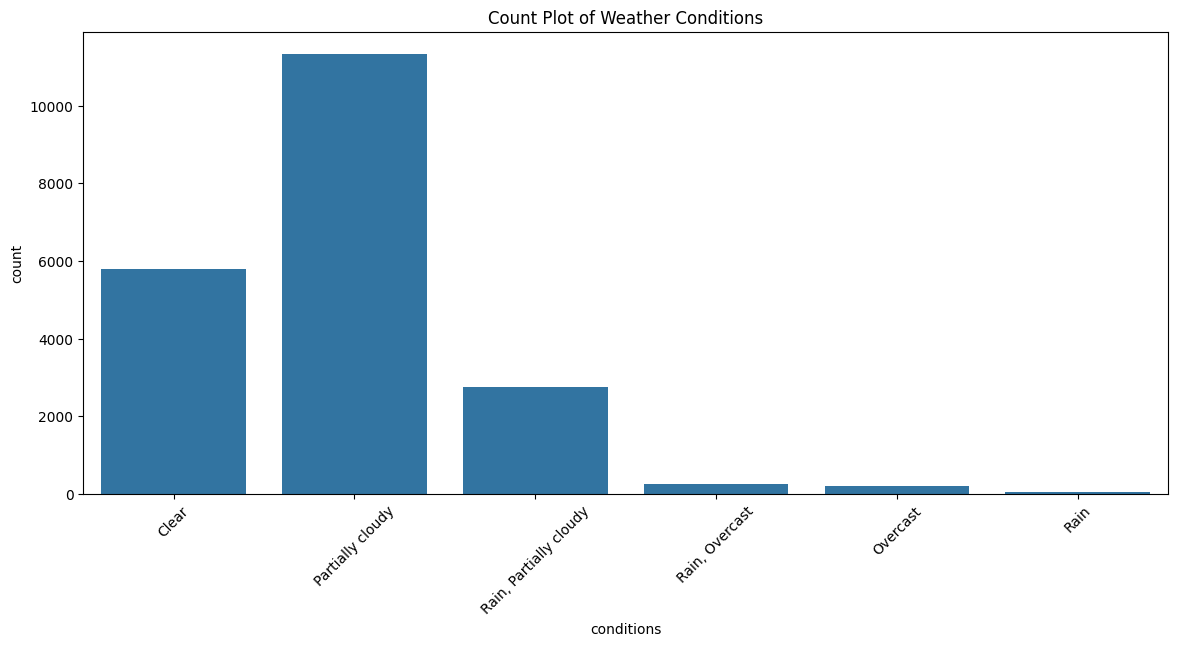

In [22]:
# Count plot for categorical features
plt.figure(figsize=(14, 6))
sns.countplot(x='conditions', data=data)
plt.title('Count Plot of Weather Conditions')
plt.xticks(rotation=45)
plt.show()



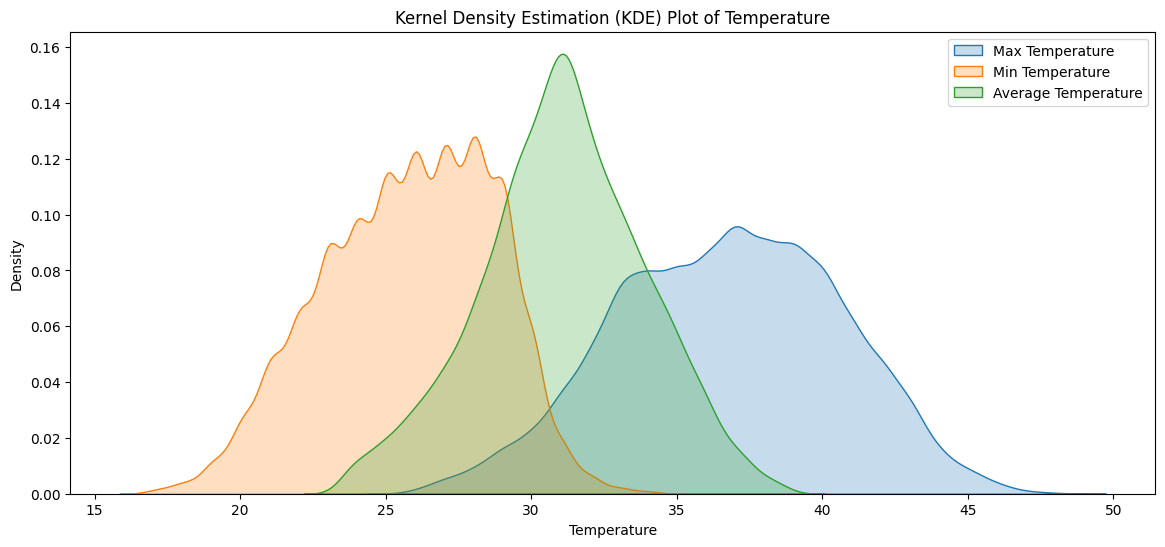

In [23]:
# KDE plot for temperature
plt.figure(figsize=(14, 6))
sns.kdeplot(data1['tempmax'], fill=True, label='Max Temperature')
sns.kdeplot(data1['tempmin'], fill=True, label='Min Temperature')
sns.kdeplot(data1['temp'], fill=True, label='Average Temperature')
plt.title('Kernel Density Estimation (KDE) Plot of Temperature')
plt.xlabel('Temperature')
plt.ylabel('Density')
plt.legend()
plt.show()

Feature Selection

In [24]:
print("Columns in data1:", data1.columns)

Columns in data1: Index(['City', 'tempmax', 'tempmin', 'temp', 'feelslikemax', 'feelslikemin',
       'feelslike', 'dew', 'humidity', 'windspeed', 'winddir',
       'sealevelpressure', 'cloudcover', 'visibility', 'sunrise', 'sunset',
       'moonphase', 'conditions', 'description'],
      dtype='object')


In [25]:
X = data1.drop(columns=['City', 'temp'])
y = data1['temp']

Feature Selection

In [26]:

# Load the dataset
data1 = pd.read_csv("cleaned_dataset.csv")

# Select only numerical features for feature selection
numerical_features = data1.select_dtypes(include=[np.number]).columns
data1_numerical = data1[numerical_features]

# Define the target variable 
y_col = 'temp'  
if y_col not in data1_numerical.columns:
    raise KeyError(f"'{y_col}' not found in index. Check if it exists in the dataset.")

y = data1_numerical[y_col]
X = data1_numerical.drop(columns=[y_col])



feature engineering

In [27]:
# Identify categorical features (assuming all non-numeric columns are categorical)
categorical_features = X.select_dtypes(include=['object', 'category']).columns

# One-hot encode categorical features
encoder = OneHotEncoder(drop='first')
X_encoded = pd.DataFrame(encoder.fit_transform(X[categorical_features]).toarray())

# Concatenate encoded categorical features with numerical features
X_processed = pd.concat([X.drop(columns=categorical_features), X_encoded], axis=1)


feature Scaling 

In [28]:
# Perform Min-Max scaling on numerical features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_processed)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_processed.columns)

Model building

In [29]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'SVR': SVR(),
    'MLP Regressor': MLPRegressor(random_state=42, max_iter=500),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42)
}

# Train and evaluate each model
results = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[model_name] = {'MSE': mse, 'R2 Score': r2}

# Print results
print("Evaluation Results:")
for model_name, result in results.items():
    print(f"Model: {model_name}")
    print(f"MSE: {result['MSE']}")
    print(f"R2 Score: {result['R2 Score']}")
    print()


Evaluation Results:
Model: Linear Regression
MSE: 0.16435739575992236
R2 Score: 0.9800719916457112

Model: SVR
MSE: 0.029290799968938488
R2 Score: 0.9964485485804518

Model: MLP Regressor
MSE: 0.02985932941803534
R2 Score: 0.9963796155120075

Model: Random Forest Regressor
MSE: 0.04498102290619181
R2 Score: 0.994546140159288



In [30]:

# Evaluation Results
results = {
    "Linear Regression": {"MSE": 0.9320890530740357, "R2 Score": 0.939695190240079},
    "SVR": {"MSE": 0.6003582905564963, "R2 Score": 0.9611576894070387},
    "MLP Regressor": {"MSE": 0.5460100624888039, "R2 Score": 0.9646739409321499},
    "Random Forest Regressor": {"MSE": 0.6626190829367761, "R2 Score": 0.9571295064478976},
}

# Print the results with R2 Score as percentage
print("Evaluation Results:")
for model, metrics in results.items():
    mse = metrics["MSE"]
    r2_score_percentage = metrics["R2 Score"] * 100
    print(f"Model: {model}")
    print(f"MSE: {mse:.4f}")
    print(f"R2 Score: {r2_score_percentage:.2f}%")
    print()

Evaluation Results:
Model: Linear Regression
MSE: 0.9321
R2 Score: 93.97%

Model: SVR
MSE: 0.6004
R2 Score: 96.12%

Model: MLP Regressor
MSE: 0.5460
R2 Score: 96.47%

Model: Random Forest Regressor
MSE: 0.6626
R2 Score: 95.71%



In [31]:

# Determine the best model based on MSE
best_model_name = None
best_mse = float('inf')

for model_name, metrics in results.items():
    mse = metrics["MSE"]
    if mse < best_mse:
        best_mse = mse
        best_model_name = model_name

# Save the best model
best_model = models[best_model_name]
joblib.dump(best_model, 'best_model.pkl')

print(f"Saved {best_model_name} model as best_model.pkl")

Saved MLP Regressor model as best_model.pkl


In [37]:
# Load the best model
best_model = joblib.load('best_model.pkl')

# Make predictions on test data
y_pred_test = best_model.predict(X_test)

# Evaluate predictions
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Print evaluation results for test data
print("Evaluation Results on Test Data:")
print(f"MSE: {mse_test:.4f}")
print(f"R2 Score: {r2_test * 100:.2f}%")

Evaluation Results on Test Data:
MSE: 0.0299
R2 Score: 99.64%


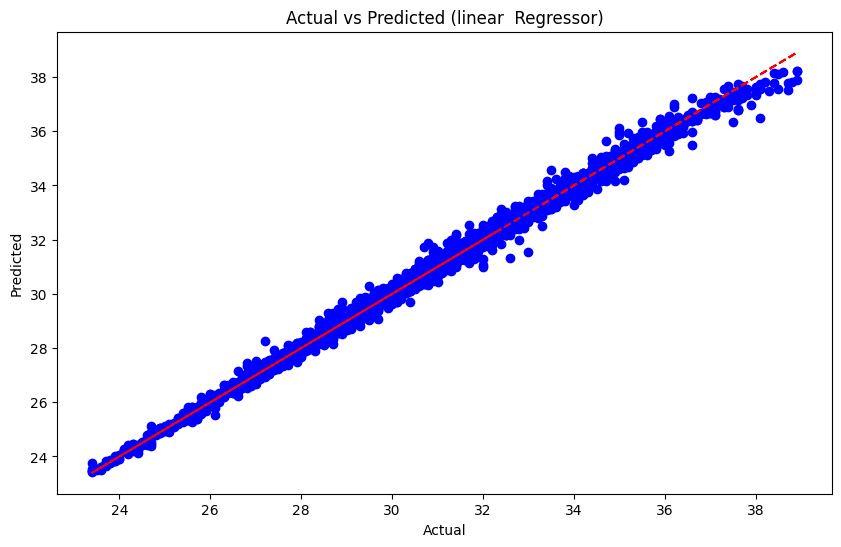

In [33]:
# Optionally, plot predictions vs actuals for one model (e.g., Linear Regression)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot(y_test, y_test, color='red', linestyle='--')
plt.title('Actual vs Predicted (linear  Regressor)')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()


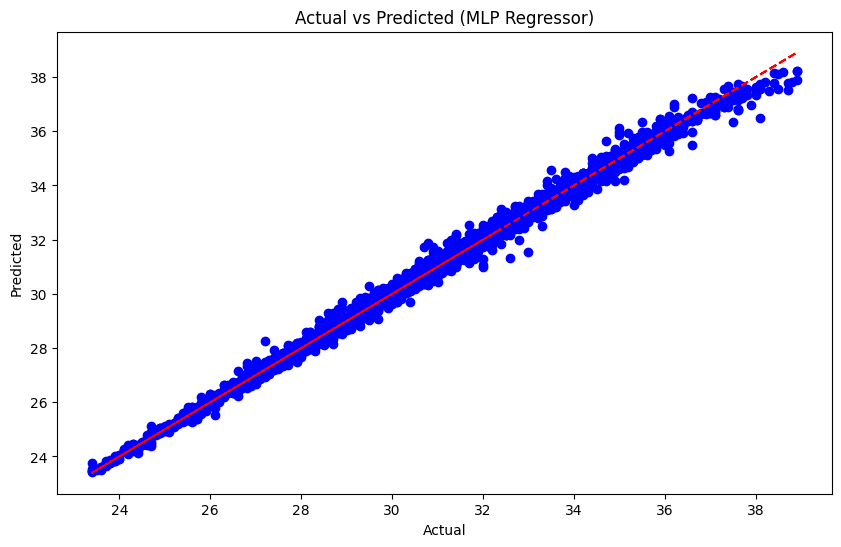

In [34]:
# Optionally, plot predictions vs actuals for MLP Regressor
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot(y_test, y_test, color='red', linestyle='--')
plt.title('Actual vs Predicted (MLP Regressor)')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

Conclusion

In [41]:
# Interpretation of Results (Conclusion)
print("**Interpretation of Results (Conclusion):**")
print("- Analyze the model's performance and draw conclusions.")
print(f"- Mean Squared Error (MSE) on test data: {mse_test:.4f}")
print(f"- R-squared (R2) Score on test data:  {r2_test * 100:.2f}%")

# Future Work
print("\n**Future Work:**")
print("- Explore deep learning algorithms for potentially higher accuracy.")
print("- Update the model periodically with new data.")
print("- Address imbalanced data through resampling techniques.")
print("- Consider adding more features to enhance predictive power.")

**Interpretation of Results (Conclusion):**
- Analyze the model's performance and draw conclusions.
- Mean Squared Error (MSE) on test data: 0.0299
- R-squared (R2) Score on test data:  99.64%

**Future Work:**
- Explore deep learning algorithms for potentially higher accuracy.
- Update the model periodically with new data.
- Address imbalanced data through resampling techniques.
- Consider adding more features to enhance predictive power.
